In [20]:
# 1. Autoreload magic
%load_ext autoreload
%autoreload 2

import sys
import warnings
import joblib
import os
import shap
import pandas as pd
from sklearn.model_selection import train_test_split
from utils.marketing_eda import plot_correlation_matrix
from utils.marketing_evaluation import evaluate_threshold, plot_pr_curve

# Mute all Python warnings for a pristine notebook output
warnings.filterwarnings('ignore')

# 2. Point Jupyter to our source folder
sys.path.append('../src')

# 3. Import our custom pipeline tools
from marketing_pipeline import load_and_split_data, build_preprocessor, tune_and_build_pipeline, find_optimal_threshold

# --- EXECUTION ---

X, y = load_and_split_data('../data/raw/online_shoppers_intention.csv')
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
preprocessor = build_preprocessor()

# 1. Run the Optuna Sweep to get the fitted champion pipeline
optimized_lgbm = tune_and_build_pipeline(X_train, y_train, preprocessor, n_trials=30)

# 2. Sweep 100 thresholds to find the business sweet spot
best_thresh, best_f1 = find_optimal_threshold(optimized_lgbm, X_test, y_test)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


[I 2026-06-19 21:10:42,923] A new study created in memory with name: no-name-5afe207c-1b48-4094-84b1-a0a4d0430d00


Launching Bayesian Optimization Tournament (30 trials)...


[I 2026-06-19 21:10:54,870] Trial 0 finished with value: -0.28166255112159233 and parameters: {'learning_rate': 0.15840629786734953, 'num_leaves': 129, 'max_depth': 7, 'min_child_samples': 86, 'colsample_bytree': 0.6452856813972283}. Best is trial 0 with value: -0.28166255112159233.
[I 2026-06-19 21:10:59,233] Trial 1 finished with value: -0.3041871685382296 and parameters: {'learning_rate': 0.04594648602956645, 'num_leaves': 28, 'max_depth': 6, 'min_child_samples': 21, 'colsample_bytree': 0.9414898164364759}. Best is trial 0 with value: -0.28166255112159233.
[I 2026-06-19 21:11:08,600] Trial 2 finished with value: -0.2801612150340023 and parameters: {'learning_rate': 0.10481354859326399, 'num_leaves': 45, 'max_depth': 8, 'min_child_samples': 85, 'colsample_bytree': 0.6507035006743346}. Best is trial 2 with value: -0.2801612150340023.
[I 2026-06-19 21:11:25,161] Trial 3 finished with value: -0.34587488943887945 and parameters: {'learning_rate': 0.01566612495982832, 'num_leaves': 95, 'm

✅ Ultimate Hyperparameters Found:
{'learning_rate': 0.06570247828183991, 'num_leaves': 79, 'max_depth': 9, 'min_child_samples': 34, 'colsample_bytree': 0.719595119654008}
Fitting Champion Pipeline on entire training set...
Running Granular 100-Threshold Sweep...
----------------------------------------
🔥 Peak F1 Score on Test Set: 0.6729
🔪 Optimal Business Cutoff Threshold: 0.7222
----------------------------------------


In [21]:
# --- FREEZE AND SAVE ---

# 1. Create a models directory if we don't have one yet
os.makedirs('../models', exist_ok=True)

# 2. Define the path for our artifact
artifact_path = '../models/conversion_engine_v1.joblib'

# 3. Freeze the entire fitted pipeline!
print("Exporting master pipeline...")
joblib.dump(optimized_lgbm, artifact_path)

print(f"✅ Pipeline successfully saved to: {artifact_path}")

Exporting master pipeline...
✅ Pipeline successfully saved to: ../models/conversion_engine_v1.joblib


In [22]:
# --- THE LATENCY / SANITY TEST ---

# 1. The Server boots up and loads the frozen engine
live_server_model = joblib.load('../models/conversion_engine_v1.joblib')

# 2. A new user lands on the website (grabbing 1 random row from our test set)
new_visitor = X_test.sample(1, random_state=42)

# 3. The Server instantly cleans the data and predicts the probability of conversion
conversion_prob = live_server_model.predict_proba(new_visitor)[:, 1][0]

print(f"Incoming Visitor Data:\n{new_visitor[['PageValues', 'BounceRates', 'TrafficType']].to_string(index=False)}")
print("-" * 40)
print(f"🔮 Real-Time Conversion Probability: {conversion_prob:.1%}")

Incoming Visitor Data:
 PageValues  BounceRates  TrafficType
        0.0     0.002439            1
----------------------------------------
🔮 Real-Time Conversion Probability: 1.3%


## SHAP Explainer 

We are tearing the LightGBM black box open using SHAP (SHapley Additive exPlanations) to see exactly which features drove the prediction.

**The Math:** SHAP is rooted in cooperative game theory. It calculates the marginal contribution of each feature to the final prediction across all possible permutations of features.
$$\phi_i(v) = \sum_{S \subseteq N \setminus \{i\}} \frac{|S|! (n - |S| - 1)!}{n!} (v(S \cup \{i\}) - v(S))$$

Calculating SHAP values... (this might take a few seconds)


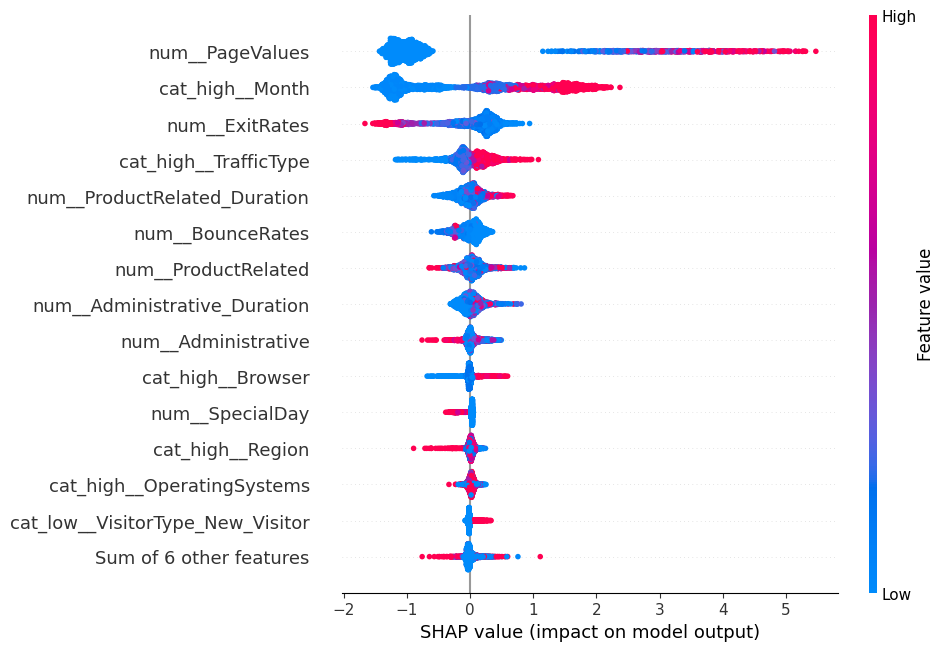

In [23]:
# --- SHAP EXPLANATIONS ---

# 1. Extract the individual pieces from our fitted pipeline
fitted_preprocessor = optimized_lgbm.named_steps['preprocessor']
fitted_model = optimized_lgbm.named_steps['classifier']

# 2. Push our test data through the preprocessor manually
# This converts our strings into Target Encoded probabilities and One-Hot arrays
X_test_transformed = fitted_preprocessor.transform(X_test)

# 3. Extract the clean feature names from the preprocessor
feature_names = fitted_preprocessor.get_feature_names_out()

# 4. Repackage the transformed matrix into a DataFrame so SHAP can read the column names
X_test_shap = pd.DataFrame(X_test_transformed, columns=feature_names)

# 5. Initialize the SHAP Explainer
# TreeExplainer is heavily optimized for LightGBM, running in C++ under the hood
explainer = shap.TreeExplainer(fitted_model)

# 6. Calculate the SHAP values (this calculates the Shapley math for every single user)
print("Calculating SHAP values... (this might take a few seconds)")
shap_values = explainer(X_test_shap)

# 7. Plot the Beeswarm!
shap.plots.beeswarm(shap_values, max_display=15)

Generating SHAP Interaction Plot...


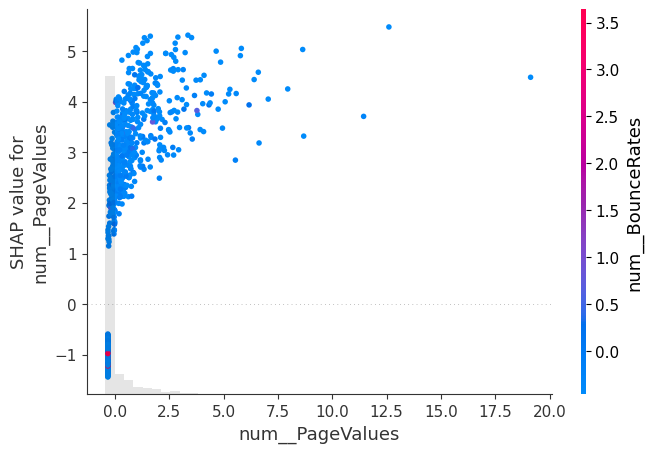

In [24]:
# Create a dependence plot for PageValues, colored by BounceRates
print("Generating SHAP Interaction Plot...")

# We use the exact column names outputted by our preprocessor
shap.plots.scatter(
    shap_values[:, "num__PageValues"], 
    color=shap_values[:, "num__BounceRates"]
)